In [1]:
target = "data/Greek/training/gold_summaries/1_1.txt"

prediction = "data/Greek/training/candidate_summaries/1_consecutively_swapped_words_0.1.txt"

In [ ]:
# def summtriver(config_path):
#     result = subprocess.check_output(
#         ["perl", "summTriver_Exp.perl", config_path],
#         cwd="evaluation_methods/SummTriver/SummTriver_src/summTriver_Exp.perl",
#         text=True
#     )
#     return result.strip().splitlines()

# # Example usage
# summtriver("evaluation_methods/SummTriver/Example/example.xml")

## Libraries

In [ ]:
import pandas as pd
import numpy as np
import os
import spacy
from dotenv import load_dotenv
from pprint import pprint
import seaborn as sns
import matplotlib.pyplot as plt

from src.summary_corruptor import SummaryCorruptor

load_dotenv()
ANNUAL_REPORTS_DIR = os.getenv('ANNUAL_REPORTS_DIR')
GOLD_SUMMARIES_DIR = os.getenv('GOLD_SUMMARIES_DIR')
CANDIDATE_SUMMARIES_DIR = os.getenv('CANDIDATE_SUMMARIES_DIR')
RESULTS_PATH = os.getenv('RESULTS_PATH')

## Candidate summaries

### Abstractive summaries with a summarization model

In [6]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("kriton/greek-text-summarization")
model = AutoModelForSeq2SeqLM.from_pretrained("kriton/greek-text-summarization")

In [7]:
def get_token_length(filepath):
    with open(filepath, mode='r', encoding='utf-8') as file:
        text = file.read()
    return len(tokenizer(text, truncation=False, padding=False)['input_ids'])

In [8]:
source_token_lengths = [
    get_token_length(ANNUAL_REPORTS_DIR+txtfile)
    for txtfile in os.listdir(ANNUAL_REPORTS_DIR)
]

goldsum_token_lengths = [
    get_token_length(GOLD_SUMMARIES_DIR+txtfile)
    for txtfile in os.listdir(GOLD_SUMMARIES_DIR)    
]

In [9]:
max_input_token_length = max(source_token_lengths)
min_output_token_length = min(goldsum_token_lengths)
max_output_token_length = max(goldsum_token_lengths)

In [10]:
print(max_input_token_length)
print(min_output_token_length)
print(max_output_token_length)

582189
1
159722


In [ ]:
from transformers import pipeline

summarizer = pipeline("summarization", model="kriton/greek-text-summarization")

def genarate_summary(article):
    inputs = tokenizer(
        'summarize: ' + article, 
        return_tensors="pt", 
        max_length=max_input_token_length, 
        truncation=True,
        padding="max_length",
    )

    outputs = model.generate(
        inputs["input_ids"], 
        max_length=max_output_token_length, 
        min_length=min_output_token_length, 
        length_penalty=3.0,
        num_beams=8, 
        early_stopping=True,
        repetition_penalty=3.0,
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

Device set to use cuda:0


In [24]:
for txtfile in os.listdir(ANNUAL_REPORTS_DIR)[:1]:
    with open(ANNUAL_REPORTS_DIR+txtfile, mode='r', encoding='utf-8') as file:
        source = file.read()
        print(genarate_summary(article=source))

Σημαντικά γεγονότα της χρήσης για το έτος που έληξε την 31η Δεκεμβρίου 2019 (Σύμφωνα με το Ν.3556/07) Ο Αναπληρωτής Διευθύνων Σύμβουλος Μάρκος Μπιτσάκος αναφέρει: Ετήσια Οικονομική Έκθεση της 31 Δεκεμβρίου 2019 (Τα ποσά παρουσιάζονται σε χιλιάδες Ευρώ εκτός εάν δηλώνεται διαφορετικά) δ


### Reduced gold summaries as candidate summaries

In [ ]:
gold_summary =  'Η έκθεση του Δ.Σ. απεικονίζει κατά τρόπο αληθή την εξέλιξη.'
corruptor = SummaryCorruptor(input_summary=gold_summary, noise_percentage=0.9)

2025-03-19 13:35:57.569 | INFO     | src.summary_destructor:__init__:49 - SummaryDestructor initialized with 90% noise.


#### Randomly swap words

In [ ]:
corruptor.random_swap_words()

2025-03-19 13:31:35.862 | DEBUG    | src.summary_destructor:_get_swap_indices:133 - Total words: 10
2025-03-19 13:31:35.862 | DEBUG    | src.summary_destructor:_get_swap_indices:136 - Number of swaps: 4
2025-03-19 13:31:35.862 | DEBUG    | src.summary_destructor:random_swap_words:156 - Number of indices to be swapped: 8
2025-03-19 13:31:35.862 | DEBUG    | src.summary_destructor:random_swap_words:157 - Indices to be swapped: [0, 3, 7, 8, 5, 2, 4, 1]
2025-03-19 13:31:35.863 | DEBUG    | src.summary_destructor:random_swap_words:164 - Indices: 0, 3 = 3, 0
2025-03-19 13:31:35.863 | DEBUG    | src.summary_destructor:random_swap_words:165 - Words: Η, Δ.Σ. = Δ.Σ., Η
2025-03-19 13:31:35.863 | DEBUG    | src.summary_destructor:random_swap_words:164 - Indices: 7, 8 = 8, 7
2025-03-19 13:31:35.863 | DEBUG    | src.summary_destructor:random_swap_words:165 - Words: αληθή, την = την, αληθή
2025-03-19 13:31:35.864 | DEBUG    | src.summary_destructor:random_swap_words:164 - Indices: 5, 2 = 2, 5
2025-03

'Δ.Σ. απεικονίζει κατά Η έκθεση του τρόπο την αληθή εξέλιξη.'

#### Consecutively swap words

In [ ]:
corruptor.consecutive_swap_words()

2025-03-19 13:31:37.551 | DEBUG    | src.summary_destructor:_get_swap_indices:133 - Total words: 10
2025-03-19 13:31:37.551 | DEBUG    | src.summary_destructor:_get_swap_indices:136 - Number of swaps: 4
2025-03-19 13:31:37.551 | DEBUG    | src.summary_destructor:consecutive_swap_words:190 - Number of indices to be swapped: 8
2025-03-19 13:31:37.551 | DEBUG    | src.summary_destructor:consecutive_swap_words:191 - Indices to be swapped: [2, 3, 5, 7]
2025-03-19 13:31:37.551 | DEBUG    | src.summary_destructor:consecutive_swap_words:198 - Indices: 2, 3 = 3, 2
2025-03-19 13:31:37.551 | DEBUG    | src.summary_destructor:consecutive_swap_words:199 - Words: κατά, Η = Η, κατά
2025-03-19 13:31:37.552 | DEBUG    | src.summary_destructor:consecutive_swap_words:198 - Indices: 5, 6 = 6, 5
2025-03-19 13:31:37.552 | DEBUG    | src.summary_destructor:consecutive_swap_words:199 - Words: του, τρόπο = τρόπο, του
2025-03-19 13:31:37.552 | DEBUG    | src.summary_destructor:consecutive_swap_words:198 - Indic

'Δ.Σ. απεικονίζει Η κατά έκθεση τρόπο του αληθή την εξέλιξη.'

#### Randomly remove words

In [ ]:
corruptor.remove_words()

2025-03-19 13:36:00.285 | DEBUG    | src.summary_destructor:remove_words:214 - Total words: 10
2025-03-19 13:36:00.285 | DEBUG    | src.summary_destructor:remove_words:217 - Number of words to be removed: 9
2025-03-19 13:36:00.285 | DEBUG    | src.summary_destructor:remove_words:219 - Words removed:
2025-03-19 13:36:00.285 | DEBUG    | src.summary_destructor:remove_words:226 - 0: τρόπο
2025-03-19 13:36:00.285 | DEBUG    | src.summary_destructor:remove_words:226 - 1: έκθεση
2025-03-19 13:36:00.286 | DEBUG    | src.summary_destructor:remove_words:226 - 2: την
2025-03-19 13:36:00.287 | DEBUG    | src.summary_destructor:remove_words:226 - 3: κατά
2025-03-19 13:36:00.287 | DEBUG    | src.summary_destructor:remove_words:226 - 4: Δ.Σ.
2025-03-19 13:36:00.287 | DEBUG    | src.summary_destructor:remove_words:226 - 5: Η
2025-03-19 13:36:00.288 | DEBUG    | src.summary_destructor:remove_words:226 - 6: εξέλιξη.
2025-03-19 13:36:00.288 | DEBUG    | src.summary_destructor:remove_words:226 - 7: του
2

'απεικονίζει'

#### Randomly remove sentences

In [ ]:
gold_summary = '''
Οι συνημμένες Χρηματοοικονομικές Καταστάσεις του Ομίλου της Χ A.E. απεικονίζουν κατά τρόπο αληθή τα στοιχεία του ενεργητικού και του παθητικού.

Η έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπο αληθή την εξέλιξη, τις επιδόσεις και τη θέση του Ομίλου και της Εταιρείας.

Αθήνα, 31 Μαρτίου 2020

Ο Πρόεδρος του Δ.Σ.
'''
corruptor = SummaryCorruptor(input_summary=gold_summary, noise_percentage=0.9)
nlp = spacy.load('el_core_news_sm')
# nlp.add_pipe('sentencizer', before='parser')

2025-03-19 13:41:40.963 | INFO     | src.summary_destructor:__init__:49 - SummaryDestructor initialized with 90% noise.


In [ ]:
corruptor.remove_sentence()

2025-03-19 13:41:43.634 | DEBUG    | src.summary_destructor:remove_sentence:238 - Total sentences: 3
2025-03-19 13:41:43.634 | DEBUG    | src.summary_destructor:remove_sentence:241 - Number of sentences to be removed: 2
2025-03-19 13:41:43.635 | DEBUG    | src.summary_destructor:remove_sentence:249 - Sentences to be removed:
2025-03-19 13:41:43.635 | DEBUG    | src.summary_destructor:remove_sentence:251 - 0:
Η έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπο αληθή την εξέλιξη, τις επιδόσεις και τη θέση του Ομίλου και της Εταιρείας.

2025-03-19 13:41:43.636 | DEBUG    | src.summary_destructor:remove_sentence:251 - 1:
Οι συνημμένες Χρηματοοικονομικές Καταστάσεις του Ομίλου της Χ A.E. απεικονίζουν κατά τρόπο αληθή τα στοιχεία του ενεργητικού και του παθητικού.



'Αθήνα, 31 Μαρτίου 2020\n\nΟ Πρόεδρος του Δ.Σ.'

#### Insert sentences from other summaries

In [ ]:
source_docs = [file[:-4] for file in os.listdir(ANNUAL_REPORTS_DIR)]

pprint(corruptor.insert_sentence(target='1', source_docs=source_docs, gold_dir=GOLD_SUMMARIES_DIR))

2025-03-19 13:41:50.785 | DEBUG    | src.summary_destructor:insert_sentence:273 - Total sentences: 3
2025-03-19 13:41:50.785 | DEBUG    | src.summary_destructor:insert_sentence:281 - Random summary: 188
2025-03-19 13:41:50.836 | DEBUG    | src.summary_destructor:insert_sentence:289 - Random summary sentences: 10
2025-03-19 13:41:50.837 | DEBUG    | src.summary_destructor:insert_sentence:292 - Number of sentences to insert: 2
2025-03-19 13:41:50.837 | DEBUG    | src.summary_destructor:insert_sentence:300 - Sentences to be inserted:
2025-03-19 13:41:50.837 | DEBUG    | src.summary_destructor:insert_sentence:302 - 0:
Α.Ε.

Ο Διευθύνων Σύμβουλος Γενικός Εκτελεστικός Διευθυντής

Το Ορισθέν από το Δ.Σ.
Μέλος

Ο.Λ.Θ.

2025-03-19 13:41:50.837 | DEBUG    | src.summary_destructor:insert_sentence:302 - 1:
Τα μέλη του Διοικητικού Συμβουλίου της Ανώνυμης Εταιρείας με την επωνυμία «ΟΡΓΑΝΙΣΜΟΣ ΛΙΜΕΝΟΣ
ΘΕΣΣΑΛΟΝΙΚΗΣ ΑΝΩΝΥΜΗ ΕΤΑΙΡΕΙΑ» και το διακριτικό τίτλο «Ο.Λ.Θ.



('Α.Ε.\n'
 '\n'
 'Ο Διευθύνων Σύμβουλος Γενικός Εκτελεστικός Διευθυντής\n'
 '\n'
 'Το Ορισθέν από το Δ.Σ.\n'
 'Μέλος\n'
 '\n'
 'Ο.Λ.Θ.Τα μέλη του Διοικητικού Συμβουλίου της Ανώνυμης Εταιρείας με την '
 'επωνυμία «ΟΡΓΑΝΙΣΜΟΣ ΛΙΜΕΝΟΣ\n'
 'ΘΕΣΣΑΛΟΝΙΚΗΣ ΑΝΩΝΥΜΗ ΕΤΑΙΡΕΙΑ» και το διακριτικό τίτλο «Ο.Λ.Θ.Οι συνημμένες '
 'Χρηματοοικονομικές Καταστάσεις του Ομίλου της Χ A.E. απεικονίζουν κατά τρόπο '
 'αληθή τα στοιχεία του ενεργητικού και του παθητικού.Η έκθεση του Διοικητικού '
 'Συμβουλίου απεικονίζει κατά τρόπο αληθή την εξέλιξη, τις επιδόσεις και τη '
 'θέση του Ομίλου και της Εταιρείας.Αθήνα, 31 Μαρτίου 2020\n'
 '\n'
 'Ο Πρόεδρος του Δ.Σ.')


#### Repeat the same sentence

In [ ]:
pprint(corruptor.repeat_sentence())

2025-03-19 13:38:00.422 | DEBUG    | src.summary_destructor:repeat_sentence:315 - Total sentences: 3
2025-03-19 13:38:00.422 | DEBUG    | src.summary_destructor:repeat_sentence:318 - Number of times to repeat: 2
2025-03-19 13:38:00.422 | DEBUG    | src.summary_destructor:repeat_sentence:322 - Sentence to be repeated: Η έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπο αληθή την εξέλιξη, τις επιδόσεις και τη θέση του Ομίλου και της Εταιρείας.


('Η έκθεση του Διοικητικού Συμβουλίου απεικονίζει κατά τρόπο αληθή την '
 'εξέλιξη, τις επιδόσεις και τη θέση του Ομίλου και της Εταιρείας.Η έκθεση του '
 'Διοικητικού Συμβουλίου απεικονίζει κατά τρόπο αληθή την εξέλιξη, τις '
 'επιδόσεις και τη θέση του Ομίλου και της Εταιρείας.Οι συνημμένες '
 'Χρηματοοικονομικές Καταστάσεις του Ομίλου της Χ A.E. απεικονίζουν κατά τρόπο '
 'αληθή τα στοιχεία του ενεργητικού και του παθητικού.Η έκθεση του Διοικητικού '
 'Συμβουλίου απεικονίζει κατά τρόπο αληθή την εξέλιξη, τις επιδόσεις και τη '
 'θέση του Ομίλου και της Εταιρείας.Αθήνα, 31 Μαρτίου 2020\n'
 '\n'
 'Ο Πρόεδρος του Δ.Σ.')


## Analysis

In [2]:
df = pd.read_csv('src/evaluation_results.csv')

In [26]:
df.sort_values(by='source_doc')

,source_doc,eval_type,eval_method,variant,score
0,1,N-gram,Rouge1,source,1.000000
222,1,Embeddings-based,BARTScore,repeated_sentence_0.3,-2.534779
221,1,Embeddings-based,BERTScore,repeated_sentence_0.3,0.976591
220,1,Meta,NPowER,repeated_sentence_0.3,0.472234
219,1,Graph-based,MeMoG,repeated_sentence_0.3,0.498534
...,...,...,...,...,...
3057,108,N-gram,Rouge2,inserted_sentence_0.5,1.000000
3056,108,N-gram,Rouge1,inserted_sentence_0.5,1.000000
3055,108,Embeddings-based,Bleurt,inserted_sentence_0.3,0.306648
3053,108,Embeddings-based,BERTScore,inserted_sentence_0.3,0.896633


In [3]:
df['variant_type'] = df['variant']
df.loc[df['variant'].str.endswith('_1'), 'variant_type'] = 'random_summary'

In [4]:
df.loc[:, 'noise_percentage'] = df.loc[df['variant_type'].str[-1:].str.isdigit(), 'variant_type'].str[-3:]
df.loc[df['variant_type'] == 'source', 'noise_percentage'] = '0.0'
df.loc[df['variant_type'].str[-1:].str.isdigit(), 'variant_type'] = df.loc[df['variant_type'].str[-1:].str.isdigit(), 'variant_type'].str[:-4]

In [29]:
df[(df['variant_type'] == 'randomly_swapped_words') & (df['eval_method'] == 'MeMoG')]['score'].describe()

count    50.000000
mean      0.780231
std       0.052142
min       0.701677
25%       0.740969
50%       0.768599
75%       0.818174
max       0.879200
Name: score, dtype: float64

In [30]:
df[(df['variant_type'] == 'randomly_swapped_words') & (df['eval_method'] == 'BARTScore')]['score'].describe()

count    50.000000
mean     -2.988012
std       0.195646
min      -3.370777
25%      -3.133845
50%      -3.029552
75%      -2.858652
max      -2.524031
Name: score, dtype: float64

### Randomly swapped words

C:\Users\Stefania\AppData\Local\Temp\ipykernel_139184\2721361148.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[(df['variant_type'] == 'randomly_swapped_words') | (df['variant_type'] == 'source')][df['eval_method'] != 'BARTScore'],


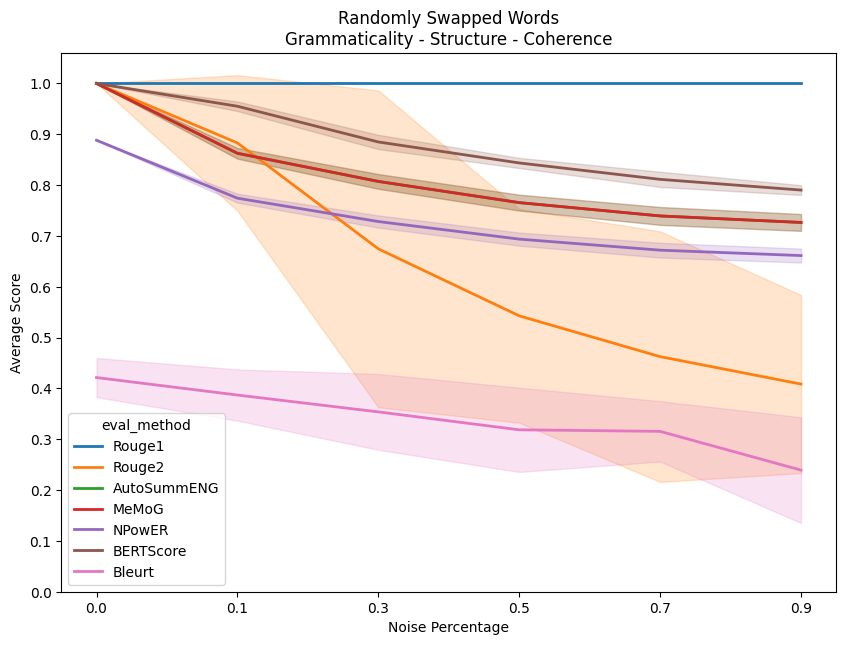

In [31]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'randomly_swapped_words') | (df['variant_type'] == 'source')][df['eval_method'] != 'BARTScore'],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Randomly Swapped Words\nGrammaticality - Structure - Coherence')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
plt.yticks(ticks=np.arange(0.0, 1.1, step=0.1))
plt.show()

C:\Users\Stefania\AppData\Local\Temp\ipykernel_139184\4101964560.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[(df['variant_type'] == 'randomly_swapped_words') | (df['variant_type'] == 'source')][df['eval_method'] == 'BARTScore'],


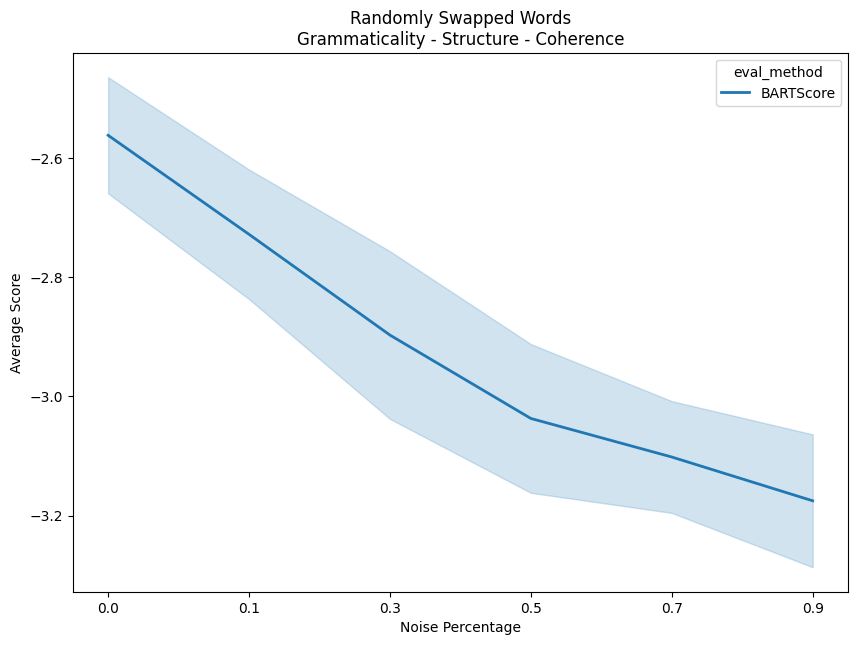

In [ ]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'randomly_swapped_words') | (df['variant_type'] == 'source')][df['eval_method'] == 'BARTScore'],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Randomly Swapped Words\nGrammaticality - Structure - Coherence')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
# plt.yticks(ticks=np.arange(0.0, 1.1, step=0.1))
plt.show()

### Consecutively swapped words

C:\Users\Stefania\AppData\Local\Temp\ipykernel_139184\3453790463.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[(df['variant_type'] == 'consecutively_swapped_words') | (df['variant_type'] == 'source')][df['eval_method'] != 'BARTScore'],


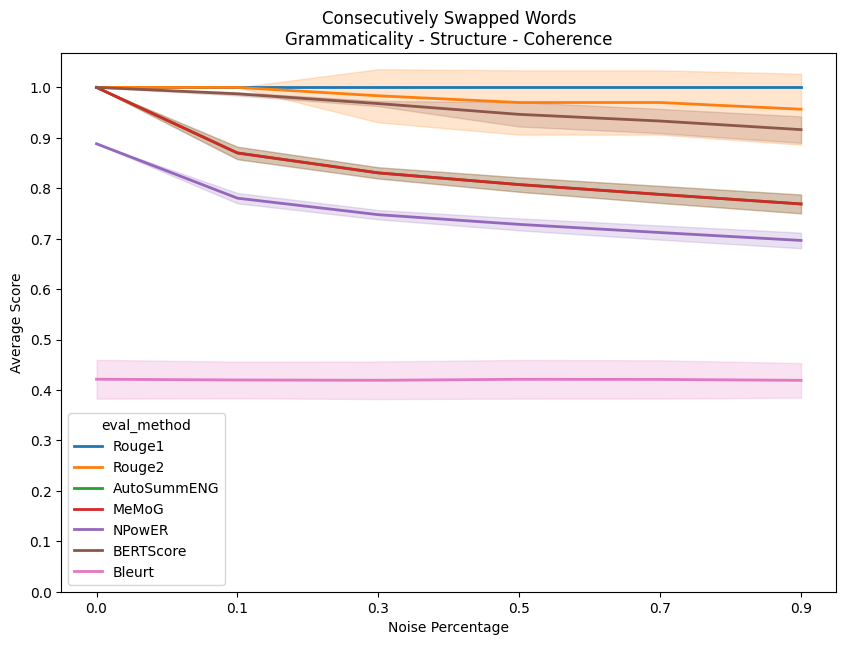

In [40]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'consecutively_swapped_words') | (df['variant_type'] == 'source')][df['eval_method'] != 'BARTScore'],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Consecutively Swapped Words\nGrammaticality - Structure - Coherence')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
plt.yticks(ticks=np.arange(0.0, 1.1, step=0.1))
plt.show()

C:\Users\Stefania\AppData\Local\Temp\ipykernel_139184\883966922.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[(df['variant_type'] == 'consecutively_swapped_words') | (df['variant_type'] == 'source')][df['eval_method'] == 'BARTScore'],


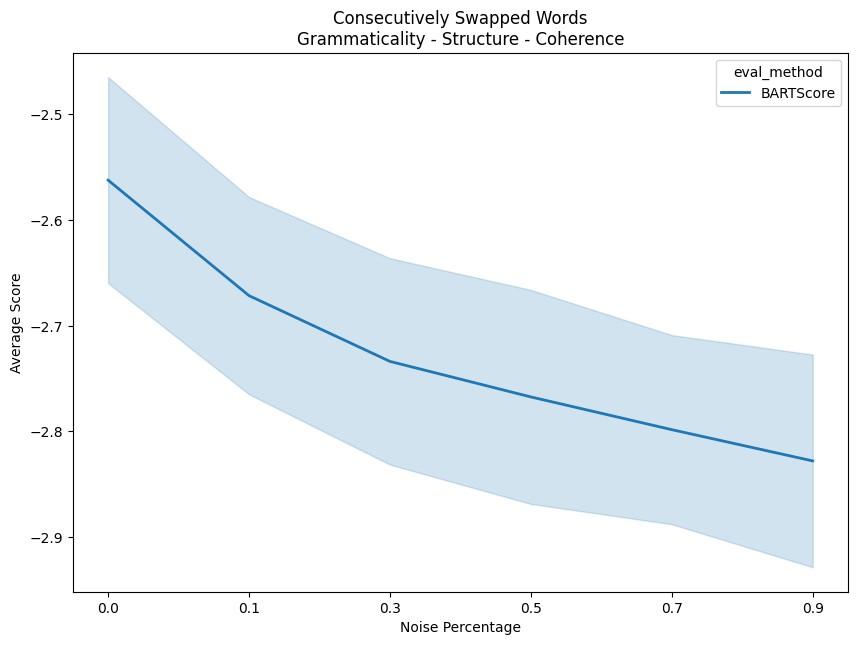

In [34]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'consecutively_swapped_words') | (df['variant_type'] == 'source')][df['eval_method'] == 'BARTScore'],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Consecutively Swapped Words\nGrammaticality - Structure - Coherence')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
# plt.yticks(ticks=np.arange(0.0, 1.1, step=0.1))
plt.show()

### Removed words

C:\Users\Stefania\AppData\Local\Temp\ipykernel_139184\3034411154.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[(df['variant_type'] == 'deleted_words') | (df['variant_type'] == 'source')][df['eval_method'] != 'BARTScore'],


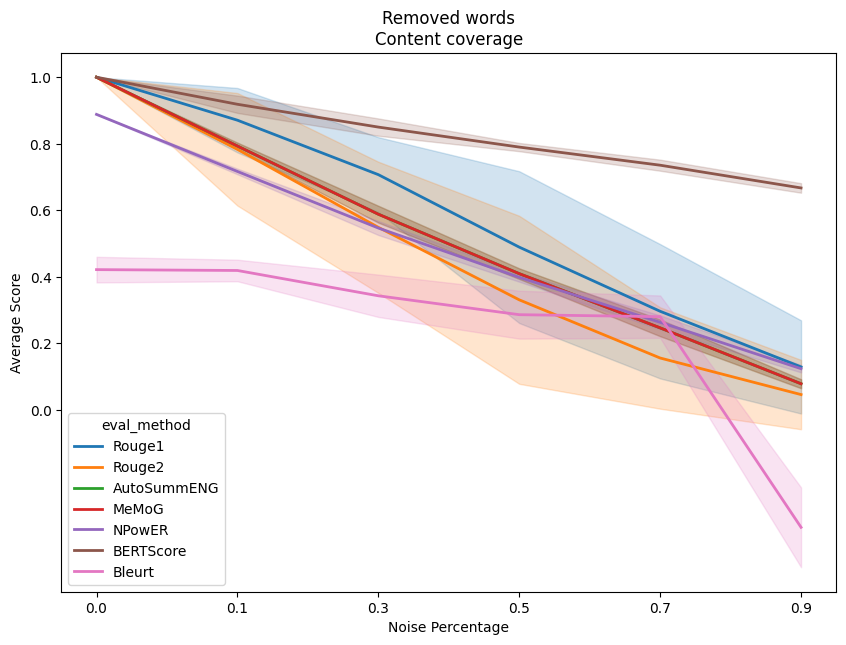

In [39]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'deleted_words') | (df['variant_type'] == 'source')][df['eval_method'] != 'BARTScore'],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Removed words\nContent coverage')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
plt.yticks(ticks=np.arange(0.0, 1.1, step=0.2))
plt.show()

C:\Users\Stefania\AppData\Local\Temp\ipykernel_139184\163418048.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[(df['variant_type'] == 'deleted_words') | (df['variant_type'] == 'source')][df['eval_method'] == 'BARTScore'],


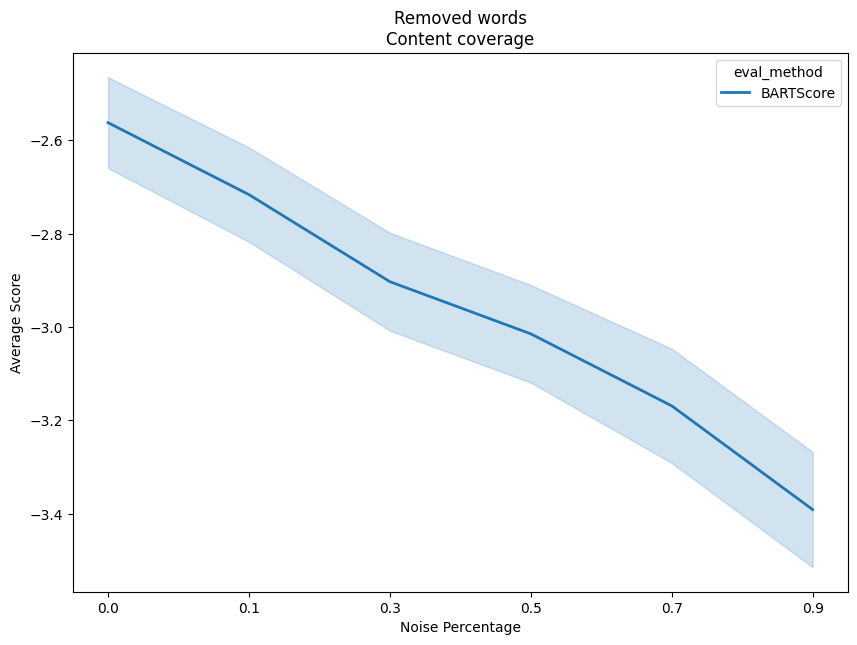

In [35]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'deleted_words') | (df['variant_type'] == 'source')][df['eval_method'] == 'BARTScore'],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Removed words\nContent coverage')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
# plt.yticks(ticks=np.arange(0.0, 1.1, step=0.2))
plt.show()

C:\Users\Stefania\AppData\Local\Temp\ipykernel_139184\51448704.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[(df['variant_type'] == 'removed_sentence') | (df['variant_type'] == 'source')][df['eval_method'] != 'BARTScore'],


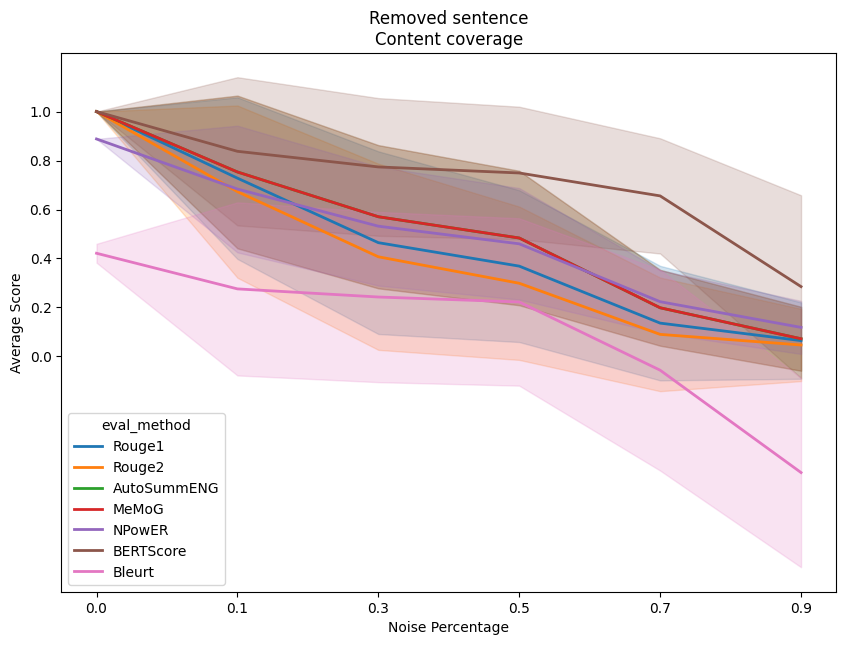

In [38]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'removed_sentence') | (df['variant_type'] == 'source')][df['eval_method'] != 'BARTScore'],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Removed sentence\nContent coverage')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
plt.yticks(ticks=np.arange(0.0, 1.1, step=0.2))
plt.show()

C:\Users\Stefania\AppData\Local\Temp\ipykernel_139184\1136577725.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[(df['variant_type'] == 'removed_sentence') | (df['variant_type'] == 'source')][df['eval_method'] == 'BARTScore'],


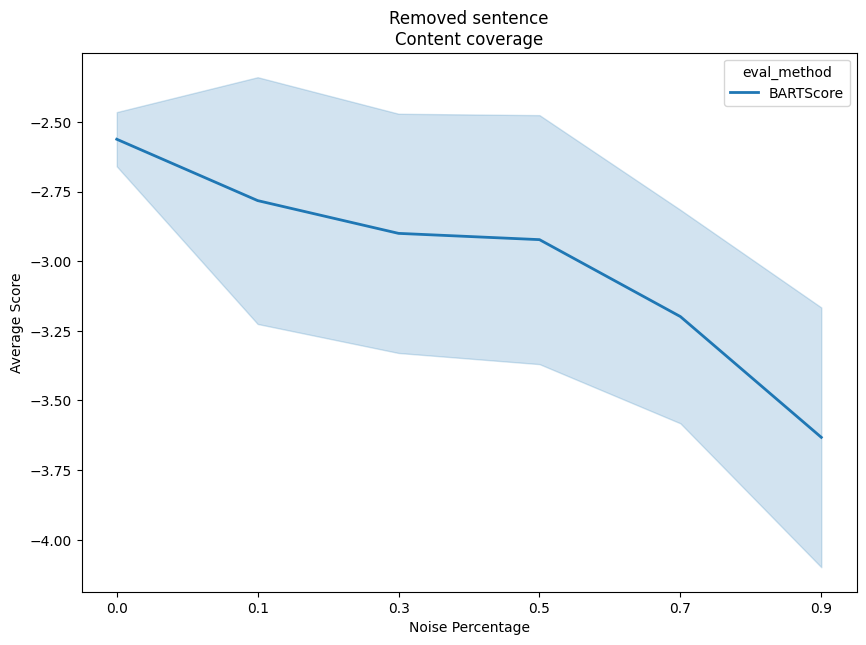

In [36]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'removed_sentence') | (df['variant_type'] == 'source')][df['eval_method'] == 'BARTScore'],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Removed sentence\nContent coverage')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
# plt.yticks(ticks=np.arange(0.0, 1.1, step=0.2))
plt.show()

C:\Users\Stefania\AppData\Local\Temp\ipykernel_139184\631081782.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[(df['variant_type'] == 'inserted_sentence') | (df['variant_type'] == 'source')][df['eval_method'] != 'BARTScore'],


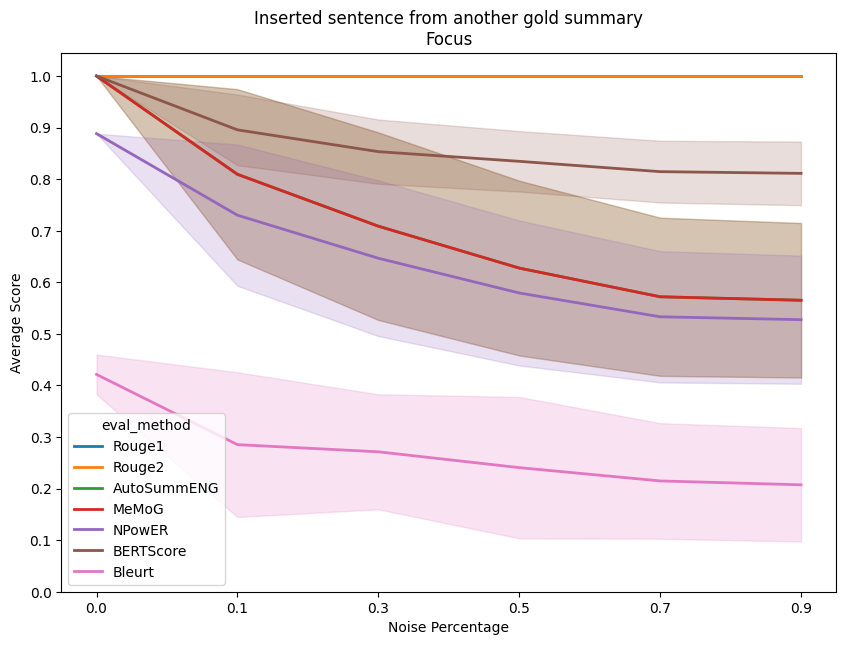

In [41]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'inserted_sentence') | (df['variant_type'] == 'source')][df['eval_method'] != 'BARTScore'],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Inserted sentence from another gold summary\nFocus')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
plt.yticks(ticks=np.arange(0.0, 1.1, step=0.1))
plt.show()

C:\Users\Stefania\AppData\Local\Temp\ipykernel_139184\848574468.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[(df['variant_type'] == 'inserted_sentence') | (df['variant_type'] == 'source')][df['eval_method'] == 'BARTScore'],


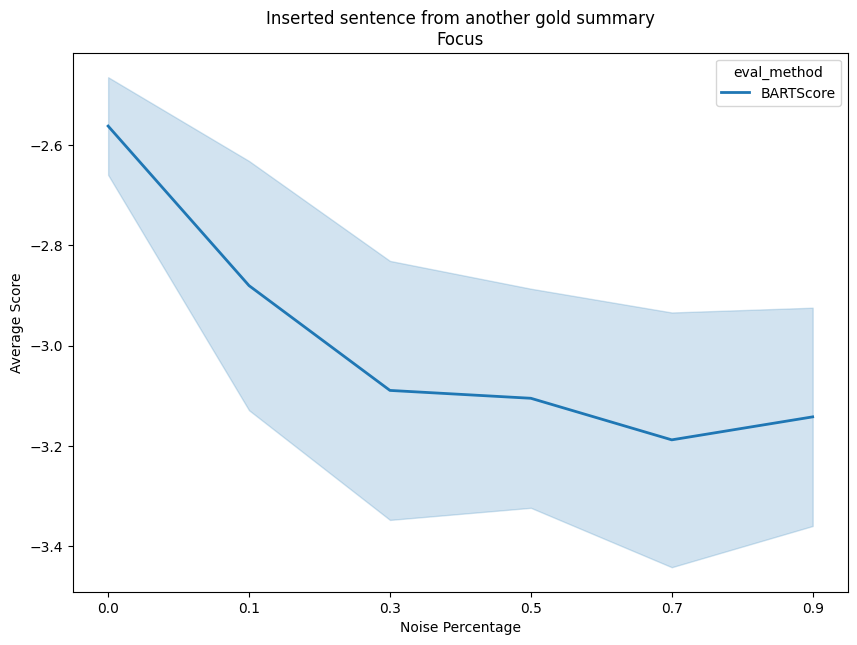

In [42]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'inserted_sentence') | (df['variant_type'] == 'source')][df['eval_method'] == 'BARTScore'],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Inserted sentence from another gold summary\nFocus')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
# plt.yticks(ticks=np.arange(0.0, 1.1, step=0.1))
plt.show()

C:\Users\Stefania\AppData\Local\Temp\ipykernel_139184\3770527765.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[(df['variant_type'] == 'repeated_sentence') | (df['variant_type'] == 'source')][df['eval_method'] != 'BARTScore'],


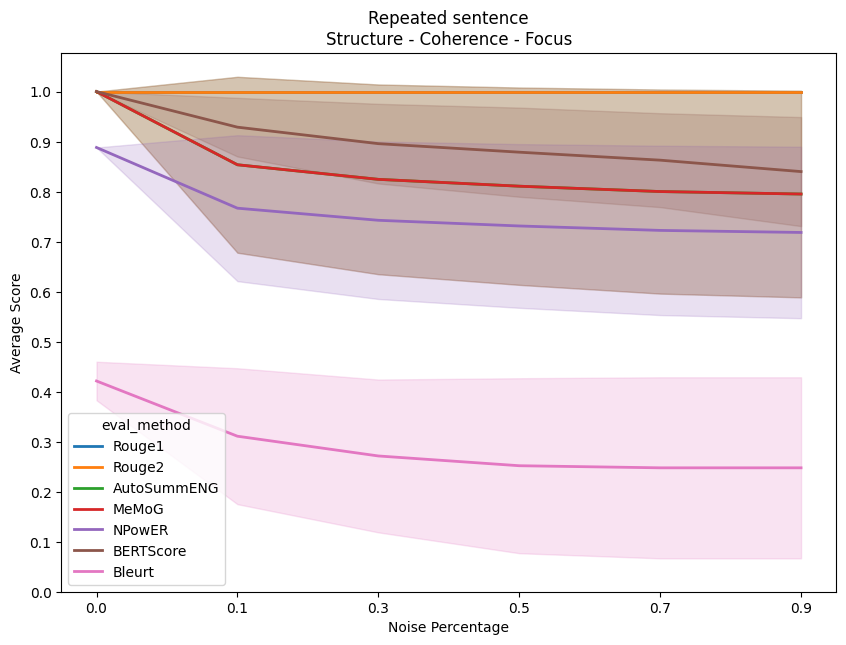

In [44]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'repeated_sentence') | (df['variant_type'] == 'source')][df['eval_method'] != 'BARTScore'],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Repeated sentence\nStructure - Coherence - Focus')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
plt.yticks(ticks=np.arange(0.0, 1.1, step=0.1))
plt.show()

C:\Users\Stefania\AppData\Local\Temp\ipykernel_139184\4008899187.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data=df[(df['variant_type'] == 'repeated_sentence') | (df['variant_type'] == 'source')][df['eval_method'] == 'BARTScore'],


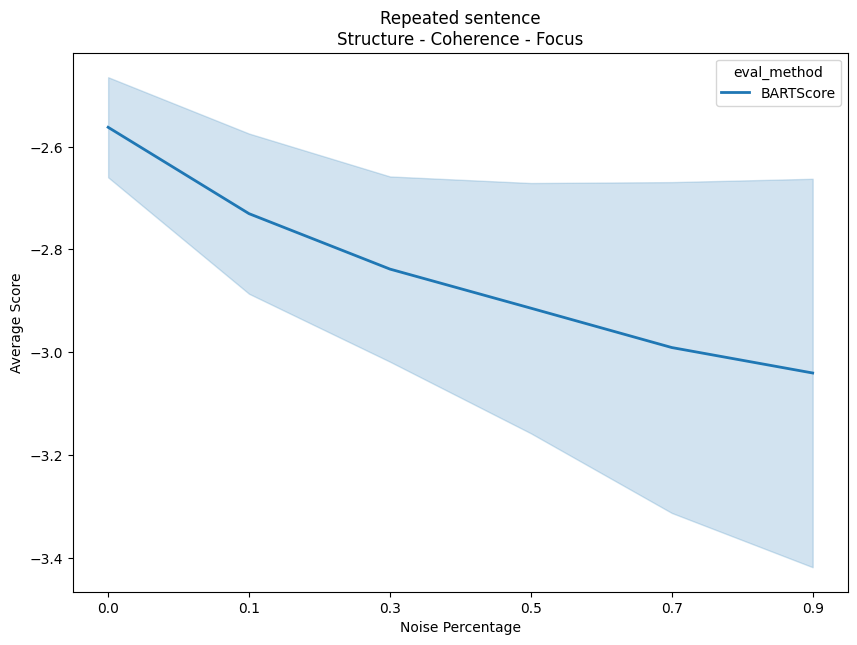

In [45]:
plt.figure(figsize=(10, 7))
sns.lineplot(
    data=df[(df['variant_type'] == 'repeated_sentence') | (df['variant_type'] == 'source')][df['eval_method'] == 'BARTScore'],
    x='noise_percentage', 
    y='score',
    hue='eval_method', 
    linewidth=2, 
    estimator=np.mean,
    errorbar='sd'
)

plt.title('Repeated sentence\nStructure - Coherence - Focus')
plt.ylabel('Average Score')
plt.xlabel('Noise Percentage')
# plt.yticks(ticks=np.arange(0.0, 1.1, step=0.1))
plt.show()

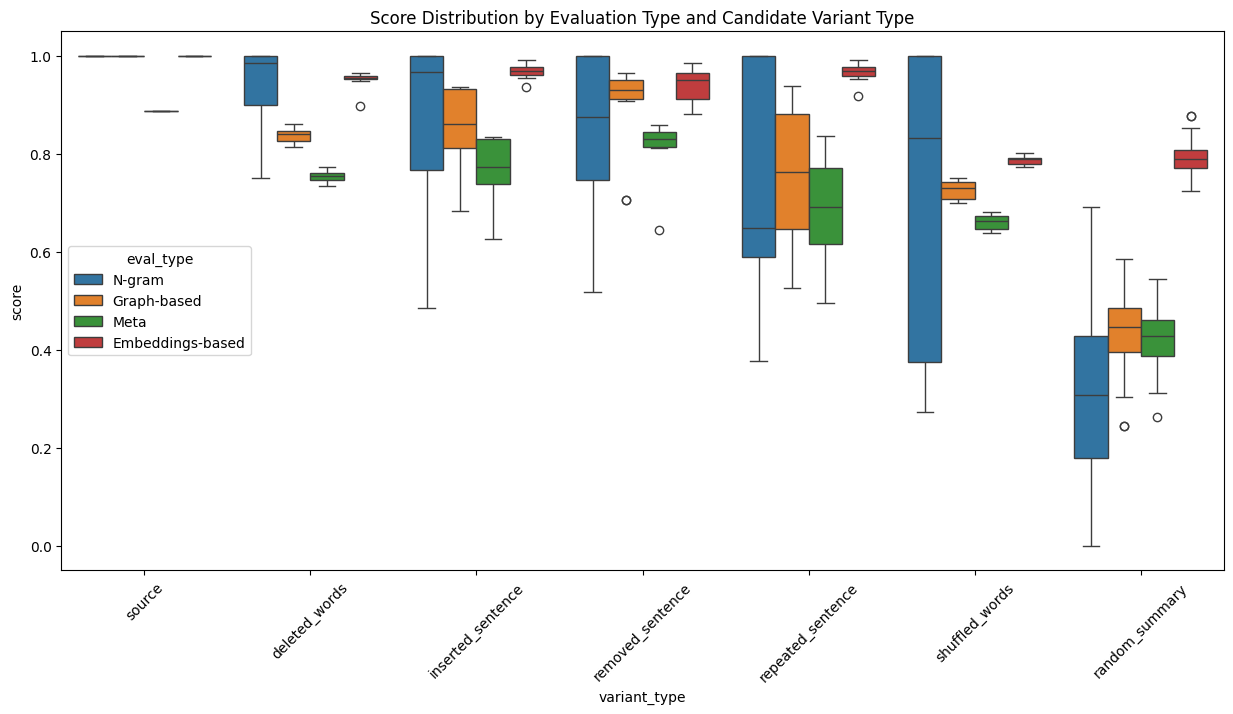

In [87]:
plt.figure(figsize=(15, 7))
sns.boxplot(data=df, x='variant_type', y='score', hue='eval_type')
plt.title('Score Distribution by Evaluation Type and Candidate Variant Type')
plt.xticks(rotation=45)
plt.show()

In [48]:
df_summary = df.groupby(['eval_type', 'variant_type'])['score'].describe().reset_index().drop(columns='count')

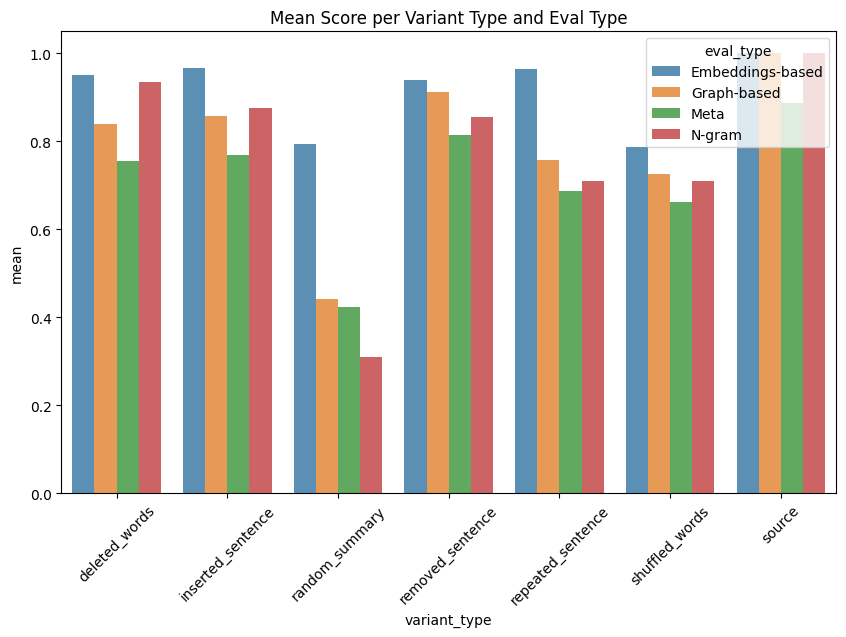

In [88]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_summary, x='variant_type', y='mean', hue='eval_type', alpha=0.8, errorbar=None)
plt.title('Mean Score per Variant Type and Eval Type')
plt.xticks(rotation=45)
plt.show()